https://docs.langchain.com/oss/python/langgraph/workflows-agents#evaluator-optimizer

In [2]:
from typing import TypedDict
from typing import Literal

from IPython.display import Image, display
import random

from langgraph.graph import StateGraph, START, END, MessagesState

class State(TypedDict):
    nodes: list[str]

class State(MessagesState):
    nodes: list[str]


def generator_node(state: State):
    return state


def evaluator_node(state: State):
    return state


builder = StateGraph(State)

builder.add_node('generator_node', generator_node)
builder.add_node('evaluator_node', evaluator_node)

builder.add_edge(START, 'generator_node')
builder.add_edge('generator_node', 'evaluator_node')
builder.add_edge('evaluator_node', END)
agent = builder.compile()

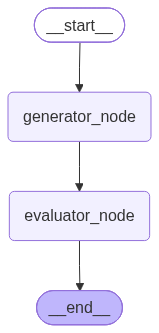

In [3]:
display(Image(agent.get_graph().draw_mermaid_png()))

Evaluator

In [4]:
from typing import TypedDict
from typing import Literal
import random

from langgraph.graph import StateGraph, START, END, MessagesState

class State(TypedDict):
    nodes: list[str]

class State(MessagesState):
    nodes: list[str]


def generator_node(state: State):
    return state


def evaluator_node(state: State):
    return state

def route_edge(state: State) -> Literal[END, "generator_node"]:
    if random.random() < 0.5:
        return END
    return "generator_node"


builder = StateGraph(State)

builder.add_node('generator_node', generator_node)
builder.add_node('evaluator_node', evaluator_node)

builder.add_edge(START, 'generator_node')
builder.add_edge('generator_node', 'evaluator_node')
builder.add_conditional_edges('evaluator_node', route_edge)

agent = builder.compile()


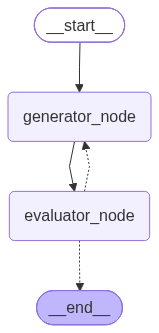

In [5]:
display(Image(agent.get_graph().draw_mermaid_png()))